# Laboratorio ConvocaUR — Andres

Workspace personal. **Lee** desde `data/`, **escribe** solo en `salidas/`.

- Catalogo: [../catalogo_datos.md](../catalogo_datos.md)
- Normas del lab: [../README.md](../README.md)
- Docs del sistema: [../../docs/](../../docs/)


## 1. Setup

Carga automatica de datasets. No edites archivos en `data/`.


In [1]:
from collections import Counter
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import pandas as pd

# Raices
PERSONA = "andres"
NB_DIR = Path.cwd()
LAB_DIR = NB_DIR.parent
CONVOCAUR = LAB_DIR.parent

sys.path.insert(0, str(CONVOCAUR / "src"))
sys.path.insert(0, str(LAB_DIR / "_comun"))

from cargar_datos import (
    cargar_todo,
    cargar_profesor,
    guardar_salida,
    salidas_dir,
)

datos = cargar_todo(persona=PERSONA, cargar_json_profesores=False)
SALIDAS = datos["salidas"]

print("Proyecto:", datos["proyecto"])
print("Salidas :", SALIDAS)
print("Docentes:", None if datos["urosario"]["docentes"] is None else len(datos["urosario"]["docentes"]))
print("JSON prof disponibles:", datos["urosario"]["n_json_disponibles"])
print("NLP convocatorias:", list(datos["minciencias"]["nlp_por_convocatoria"].keys()))

Proyecto: D:\Descargas 2\Proyecto SAMSUNG\trabajo\convocaur
Salidas : D:\Descargas 2\Proyecto SAMSUNG\trabajo\convocaur\laboratorio\andres\salidas
Docentes: 613
JSON prof disponibles: 612
NLP convocatorias: ['convocatoria_45', 'convocatoria_48', 'convocatoria_976']


## 2. Atajos a variables frecuentes


In [2]:
# --- Minciencias ---
listado = datos["minciencias"]["listado"]
actividades = datos["minciencias"]["actividades"]
documentos = datos["minciencias"]["documentos"]

nlp = datos["minciencias"]["nlp_por_convocatoria"]
secciones = datos["minciencias"]["secciones_por_convocatoria"]
elegibilidad = datos["minciencias"]["elegibilidad_por_convocatoria"]

# --- Rosario ---
docentes = datos["urosario"]["docentes"]
sin_cvlac = datos["urosario"]["sin_cvlac"]

print(listado.head(3) if listado is not None else None)
if "convocatoria_48" in nlp:
    print("Objetivo 48:", (nlp["convocatoria_48"].get("objetivo") or "")[:240])
    print("Elegibilidad 48:", elegibilidad.get("convocatoria_48", {}).get("veredicto_final"))


   numero                                             titulo  \
0   978.0  Convocatoria Fortalecimiento De Capacidades Na...   
1    48.0  CONVOCATORIA DE LA ASIGNACIÓN PARA LA CIENCIA,...   
2   977.0  Convocatoria de Clasificación y Reconocimiento...   

                            url_detalle  \
0  https://minciencias.gov.co/node/9542   
1  https://minciencias.gov.co/node/9531   
2  https://minciencias.gov.co/node/9343   

                                         descripcion total_recursos_texto  \
0  Impulsar la investigación, el desarrollo y la ...     $109.000.000.000   
1  Contribuir al fortalecimiento de las capacidad...     $749.982.430.291   
2  Medir la calidad y el impacto de la producción...                  NaN   

        fecha_apertura_texto  
0  Miércoles, Julio 15, 2026  
1     Martes, Junio 16, 2026  
2   Miércoles, Abril 8, 2026  
Objetivo 48: Contribuir al fortalecimiento de las capacidades territoriales, el conocimiento y el uso sostenible de la biodiversidad, pro

## 3. Sugerencias de codigo limpio (ConvocaUR)

1. **No mutar raw/processed.** Si transformas, guarda en `SALIDAS`.
2. **Una responsabilidad por celda** (cargar / transformar / visualizar / exportar).
3. **Nombres claros:** `df_docentes`, `nlp_48`, no `df`, `x`, `tmp2`.
4. **Paths via loader** (`cargar_datos` / `convocaur.paths`), no strings absolutos.
5. **Funciones pequenas** si reutilizas logica (>15 lineas -> `def` o PR a `src/`).
6. **Seeds** si hay muestreo aleatorio.
7. **No subir secretos** ni pegar API keys en el notebook.
8. **Exports reproducibles** con `guardar_salida(PERSONA, "archivo.csv", df)`.
9. Si algo sirve al equipo, muevelo a `src/convocaur/` con PR.


## 4. Tu espacio de trabajo

Ejemplos de partida (borralos si no los usas).


In [3]:
# Ejemplo A: explorar NLP de una convocatoria
conv = "convocatoria_48"
if conv in nlp:
    nlp_48 = nlp[conv]
    print("Alianza obligatoria:", nlp_48.get("alianza_obligatoria"))
    print("N actores:", len(nlp_48.get("actores_elegibles") or []))
    print("N requisitos:", len(nlp_48.get("requisitos") or []))
    print("N criterios:", len(nlp_48.get("criterios_evaluacion") or []))
    print("Financiacion:", nlp_48.get("financiacion"))


Alianza obligatoria: True
N actores: 8
N requisitos: 17
N criterios: 3
Financiacion: {'monto_total_texto': 'Setecientos cuarenta y nueve mil novecientos ochenta y dos millones cuatrocientos treinta mil doscientos noventa y uno ($749.982.430.291)', 'monto_total_cop': 749982430291.0, 'plazo_min_meses': 36, 'plazo_max_meses': 48, 'contrapartida_pct_min': None, 'contrapartida_pct_max': None, 'fuente_recursos': 'Sistema General de Regalías – Asignación para la Ciencia, Tecnología e Innovación, bienio 2025–2026', 'notas': 'No se especifica porcentaje de contrapartida. Los recursos se distribuyen en 6 regiones y 2 modalidades. Monto por proyecto entre $12.000.000.000 y $15.624.633.964.'}


In [4]:
# Ejemplo B: docentes con/sin CvLAC
if docentes is not None and sin_cvlac is not None:
    print("Docentes:", len(docentes))
    print("Sin CvLAC:", len(sin_cvlac))
    perfil_demo = cargar_profesor("ricardo-abello-galvis")
    print(perfil_demo.keys())
    print((perfil_demo.get("cvlac") or {}).get("datos_generales"))
    pass

Docentes: 613
Sin CvLAC: 259
dict_keys(['url', 'nombre', 'cargo_principal', 'email', 'telefono', 'imagen', 'afiliaciones', 'enlaces_externos', 'areas_investigacion', 'perfil_profesional', 'formacion_academica', 'publicaciones', 'total_publicaciones', 'proyectos', 'servicios', 'reconocimientos', 'identidad', 'id', 'facultad_csv', 'cargo_csv', 'cvlac'])
{'nota': 'Par evaluador reconocido por Minciencias.', 'Categoría': 'Investigador Asociado (I) con vigencia hasta la publicación de los resultados de la siguiente convocatoria', 'Nombre': 'Ricardo ABELLO GALVIS', 'Nombre en citaciones': 'ABELLO GALVIS, RICARDO', 'Nacionalidad': 'Colombiana', 'Sexo': 'Femenino'}


In [5]:
# Ejemplo C: guardar un resultado en TU carpeta salidas/
df_demo = listado[["numero", "titulo"]].head(5) if listado is not None else None
if df_demo is not None:
    ruta = guardar_salida(PERSONA, "demo_listado_head.csv", df_demo)
    print("Guardado en", ruta)
pass

Guardado en D:\Descargas 2\Proyecto SAMSUNG\trabajo\convocaur\laboratorio\andres\salidas\demo_listado_head.csv


## 5. Zona libre

Celdas vacias para tu analisis.


## 6. Panorama de convocatorias Minciencias

`total_recursos_texto` viene como string (`"$749.982.430.291"`). Lo parseamos a numero para poder ordenar/agregar.

In [6]:
def parse_monto_cop(texto: str) -> float | None:
    if not isinstance(texto, str):
        return None
    limpio = re.sub(r"[^0-9]", "", texto)
    return float(limpio) if limpio else None

df_convocatorias = listado.copy()
df_convocatorias["monto_cop"] = df_convocatorias["total_recursos_texto"].apply(parse_monto_cop)

print(f"Con monto identificado: {df_convocatorias['monto_cop'].notna().sum()} de {len(df_convocatorias)}")
df_convocatorias[["numero", "titulo", "monto_cop", "fecha_apertura_texto"]].sort_values(
    "monto_cop", ascending=False
).head(5)

Con monto identificado: 14 de 15


,numero,titulo,monto_cop,fecha_apertura_texto
1,48.0,"CONVOCATORIA DE LA ASIGNACIÓN PARA LA CIENCIA,...",7.499824e+11,"Martes, Junio 16, 2026"
14,46.0,CONVOCATORIA COLOMBIA INTELIGENTE: INFRAESTRUC...,6.300000e+11,"Martes, Octubre 14, 2025"
8,47.0,AGRO POR LA VIDA Y POR LA TIERRA: GARANTIZAR E...,4.465150e+11,"Jueves, Marzo 12, 2026"
7,49.0,CONVOCATORIA ENERGÍA SOSTENIBLE PARA EL TERRIT...,3.776400e+11,"Jueves, Marzo 12, 2026"
5,975.0,Convocatoria de “Becas para El Cambio” Formaci...,2.795880e+11,"Viernes, Marzo 13, 2026"


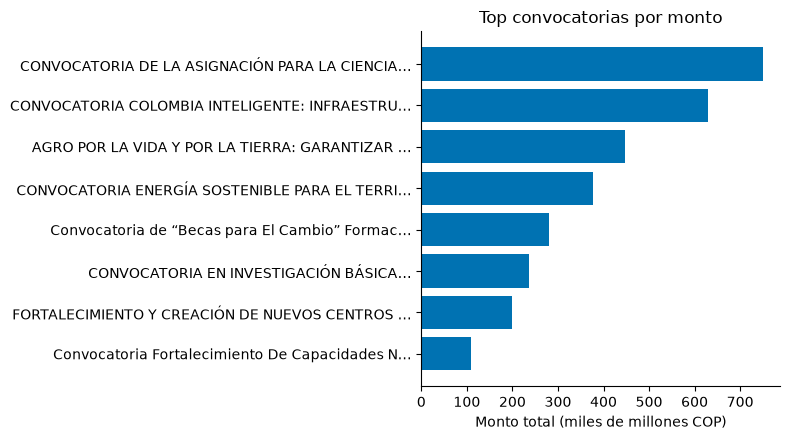

In [7]:
top_montos = df_convocatorias.dropna(subset=["monto_cop"]).sort_values("monto_cop").tail(8).copy()
top_montos["titulo_corto"] = top_montos["titulo"].str.slice(0, 45) + "…"

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top_montos["titulo_corto"], top_montos["monto_cop"] / 1e9, color="#0072B2")
ax.set_xlabel("Monto total (miles de millones COP)")
ax.set_title("Top convocatorias por monto")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## 7. Comparativo NLP + elegibilidad (piloto 48 / 45 / 976)

Une lo tipado (`nlp_por_convocatoria`) con el veredicto de elegibilidad (`elegibilidad_por_convocatoria`, clave `veredicto_final`). Util como tabla resumen para priorizar convocatorias.

In [8]:
filas_comparativo = []
for conv_id, info in nlp.items():
    fin = info.get("financiacion") or {}
    veredicto = elegibilidad.get(conv_id, {}).get("veredicto_final", {})
    filas_comparativo.append({
        "convocatoria": conv_id,
        "alianza_obligatoria": info.get("alianza_obligatoria"),
        "n_actores": len(info.get("actores_elegibles") or []),
        "n_requisitos": len(info.get("requisitos") or []),
        "n_criterios": len(info.get("criterios_evaluacion") or []),
        "monto_total_cop": fin.get("monto_total_cop"),
        "plazo_max_meses": fin.get("plazo_max_meses"),
        "puede_postularse": veredicto.get("puede_postularse"),
        "modo": veredicto.get("modo"),
        "rol_sugerido": veredicto.get("rol_sugerido"),
    })

df_comparativo = pd.DataFrame(filas_comparativo).sort_values("convocatoria").reset_index(drop=True)
guardar_salida(PERSONA, "comparativo_nlp_elegibilidad_piloto.csv", df_comparativo)
df_comparativo

,convocatoria,alianza_obligatoria,n_actores,n_requisitos,n_criterios,monto_total_cop,plazo_max_meses,puede_postularse,modo,rol_sugerido
0,convocatoria_45,False,5,25,6,2.000000e+11,36,True,puede_sola_o_alianza,ejecutora
1,convocatoria_48,True,8,17,3,7.499824e+11,48,True,solo_en_alianza,ejecutora
2,convocatoria_976,True,4,15,11,2.400000e+10,14,True,solo_en_alianza,ejecutora


## 8. Capacidad Rosario: perfiles completos, cobertura CvLAC y categorias

Cargamos los 612 JSON de `json_profesores/` (~16 MB, liviano) para extraer facultad, categoria CvLAC y un texto de perfil (`areas_investigacion` + `lineas_investigacion`) que reutilizamos en la seccion 9. No se guarda todo en `datos`, solo lo necesario en `df_perfiles`.

In [8]:
STOPWORDS_ES = {
    "para", "con", "del", "los", "las", "que", "como", "entre", "sobre",
    "desde", "hacia", "este", "esta", "estos", "estas", "mediante", "dentro",
}

def tokenizar(texto: str | None) -> list[str]:
    return [w for w in re.findall(r"[a-záéíóúñ]{6,}", (texto or "").lower()) if w not in STOPWORDS_ES]

def categoria_simple(categoria: str | None) -> str | None:
    if not isinstance(categoria, str):
        return None
    m = re.search(r"Investigador\s+(Junior|Asociado|Senior|Em[eé]rito)", categoria)
    return m.group(0) if m else categoria[:40]

registros_perfiles = []
for _, fila in docentes.iterrows():
    try:
        perfil = cargar_profesor(fila["id"])
    except FileNotFoundError:
        continue
    cv = perfil.get("cvlac")
    texto = " ".join(perfil.get("areas_investigacion") or [])
    if cv:
        texto += " " + " ".join(cv.get("lineas_investigacion") or [])
    registros_perfiles.append({
        "id": fila["id"],
        "facultad": fila["facultad"],
        "tiene_cvlac": cv is not None,
        "categoria_cvlac": categoria_simple(((cv or {}).get("datos_generales") or {}).get("Categoría")),
        "n_areas_investigacion": len(perfil.get("areas_investigacion") or []),
        "n_publicaciones": perfil.get("total_publicaciones") or 0,
        "texto_perfil": texto,
    })

df_perfiles = pd.DataFrame(registros_perfiles)
df_perfiles["tokens_perfil"] = df_perfiles["texto_perfil"].apply(tokenizar)
print(f"Perfiles cargados: {len(df_perfiles)}")
df_perfiles.drop(columns=["texto_perfil", "tokens_perfil"]).head(3)

Perfiles cargados: 612


,id,facultad,tiene_cvlac,categoria_cvlac,n_areas_investigacion,n_publicaciones
0,ricardo-abello-galvis,Facultad de Jurisprudencia,True,Investigador Asociado,8,71
1,yeny-yasbleidy-acosta-ampudia,Escuela de Medicina y Ciencias de la Salud,True,Investigador Senior,3,83
2,paula-maria-acosta-arango,Facultad de Creación,False,NaN,4,0


In [9]:
print("Categoria CvLAC (simplificada):")
print(df_perfiles["categoria_cvlac"].value_counts(dropna=False))
print()

tabla_cobertura = pd.crosstab(df_perfiles["facultad"], df_perfiles["tiene_cvlac"])
guardar_salida(PERSONA, "cobertura_cvlac_por_facultad.csv", tabla_cobertura.reset_index())
tabla_cobertura

Categoria CvLAC (simplificada):
categoria_cvlac
NaN                      424
Investigador Junior       86
Investigador Senior       54
Investigador Asociado     46
Investigador Emérito       2
Name: count, dtype: int64



tiene_cvlac,False,True
facultad,,
Decanatura del Medio Universitario,7,2
Editorial de la Universidad del Rosario,0,1
Escuela de Administración,16,20
Escuela de Ciencias e Ingeniería,15,35
"Escuela de Estudios Sociales, Políticos e Internacionales",13,48
Escuela de Medicina y Ciencias de la Salud,154,181
Facultad de Creación,23,7
Facultad de Economía,22,12
Facultad de Jurisprudencia,8,42


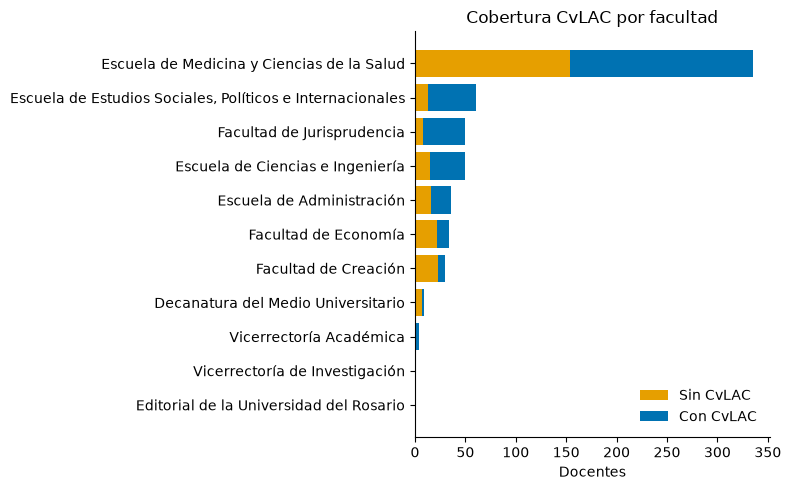

In [10]:
tabla_ordenada = tabla_cobertura.loc[tabla_cobertura.sum(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(tabla_ordenada.index, tabla_ordenada[False], color="#E69F00", label="Sin CvLAC")
ax.barh(tabla_ordenada.index, tabla_ordenada[True], left=tabla_ordenada[False], color="#0072B2", label="Con CvLAC")
ax.set_xlabel("Docentes")
ax.set_title("Cobertura CvLAC por facultad")
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## 9. Prototipo de matching por palabras clave (anticipo del roadmap de embeddings)

Baseline **muy simple** antes de construir embeddings (ver [roadmap_matching.md](../../docs/roadmap_matching.md), pasos 1-3): sacamos las palabras mas frecuentes del `objetivo` + `lineas_tematicas` de cada convocatoria y contamos cuantas aparecen en el texto de perfil (`areas_investigacion` + `lineas_investigacion`) de cada docente.

Reglas que ya aplicamos siguiendo el roadmap:

1. **No rankear convocatorias no elegibles** — filtramos por `veredicto_final.puede_postularse` antes de armar shortlist (paso 1 del roadmap).
2. **Score con señal de evidencia** — +1 si el docente tiene CvLAC, +1 si su categoria es Senior/Asociado (mejor evidencia que Junior/sin categoria).
3. **Cobertura mínima** — marcamos `equipo_suficiente = "parcial"` si hay al menos 1 Senior/Asociado en el top-15 (paso 3 del roadmap); si no, `"insuficiente"`.

Limitaciones conocidas (por diseno, no bugs): coincidencia por palabra suelta sin semantica, no distingue sinonimos, no usa grupos A1/A/B/C (aun no tabulados). Sirve como shortlist inicial a revisar a mano, no como ranking final.

In [11]:
CATEGORIAS_FUERTES = {"Investigador Senior", "Investigador Asociado"}

def extraer_palabras_clave(info_conv: dict, top_n: int = 20) -> set[str]:
    texto = (info_conv.get("objetivo") or "") + " " + " ".join(
        lt.get("nombre") or "" for lt in info_conv.get("lineas_tematicas") or []
    )
    return {w for w, _ in Counter(tokenizar(texto)).most_common(top_n)}

In [12]:
def construir_shortlist(conv_id: str, top_n: int = 15) -> tuple[set[str], pd.DataFrame]:
    palabras_clave = extraer_palabras_clave(nlp[conv_id])
    df = df_perfiles.copy()
    df["coincidencias"] = df["tokens_perfil"].apply(lambda tokens: sorted(palabras_clave & set(tokens)))
    df["n_coincidencias"] = df["coincidencias"].apply(len)
    df["score"] = (
        df["n_coincidencias"]
        + df["tiene_cvlac"].astype(int)
        + df["categoria_cvlac"].isin(CATEGORIAS_FUERTES).astype(int)
    )
    candidatos = (
        df[df["n_coincidencias"] > 0]
        .sort_values("score", ascending=False)
        .drop(columns=["texto_perfil", "tokens_perfil"])
        .reset_index(drop=True)
    )
    return palabras_clave, candidatos.head(top_n)

In [13]:
resumen_cobertura = []
shortlists_por_convocatoria = {}

for conv_id, info_conv in nlp.items():
    veredicto = elegibilidad.get(conv_id, {}).get("veredicto_final", {})
    if not veredicto.get("puede_postularse"):
        print(f"Salto {conv_id}: Rosario no es elegible")
        continue

    palabras_clave, top_candidatos = construir_shortlist(conv_id)
    shortlists_por_convocatoria[conv_id] = top_candidatos
    guardar_salida(PERSONA, f"shortlist_keyword_{conv_id}.csv", top_candidatos)

    tiene_cobertura_fuerte = top_candidatos["categoria_cvlac"].isin(CATEGORIAS_FUERTES).any()
    resumen_cobertura.append({
        "convocatoria": conv_id,
        "modo_elegibilidad": veredicto.get("modo"),
        "n_palabras_clave": len(palabras_clave),
        "n_candidatos_top": len(top_candidatos),
        "tiene_senior_o_asociado_en_top": tiene_cobertura_fuerte,
        "equipo_suficiente": "parcial" if tiene_cobertura_fuerte else "insuficiente",
    })

df_resumen_cobertura = pd.DataFrame(resumen_cobertura)
guardar_salida(PERSONA, "resumen_cobertura_piloto.csv", df_resumen_cobertura)
df_resumen_cobertura

,convocatoria,modo_elegibilidad,n_palabras_clave,n_candidatos_top,tiene_senior_o_asociado_en_top,equipo_suficiente
0,convocatoria_45,puede_sola_o_alianza,19,15,True,parcial
1,convocatoria_48,solo_en_alianza,20,15,True,parcial
2,convocatoria_976,solo_en_alianza,20,15,True,parcial


In [16]:
# Detalle de una convocatoria puntual (cambia la clave para inspeccionar otra)
shortlists_por_convocatoria["convocatoria_48"].head(10)

,id,facultad,tiene_cvlac,categoria_cvlac,n_areas_investigacion,n_publicaciones,coincidencias,n_coincidencias,score
0,juan-manuel-roberto-posada-hostettler,Escuela de Ciencias e Ingeniería,True,Investigador Senior,5,48,"[ecológica, gestión, investigación, restauración]",4,6
1,juan-alberto-castillo-martinez,Escuela de Medicina y Ciencias de la Salud,True,Investigador Senior,2,78,"[conocimiento, desarrollo, sistemas]",3,5
2,nicola-clerici,Escuela de Ciencias e Ingeniería,True,Investigador Asociado,5,76,"[monitoreo, servicios]",2,4
3,juan-miguel-gallego-acevedo,Vicerrectoría de Investigación,True,Investigador Senior,3,59,"[conocimiento, desarrollo]",2,4
4,amparo-susana-mogollon-perez,Escuela de Medicina y Ciencias de la Salud,True,Investigador Senior,6,67,"[gestión, servicios]",2,4
5,diana-rocio-bernal-camargo,Facultad de Jurisprudencia,True,Investigador Senior,4,38,"[desarrollo, investigación]",2,4
6,andre-josafat-riveros-rivera,Escuela de Ciencias e Ingeniería,True,Investigador Senior,5,42,"[capacidades, sistemas]",2,4
7,lizeth-fernanda-serrano-cardenas,Escuela de Administración,True,Investigador Asociado,5,16,"[conocimiento, gestión]",2,4
8,pedro-mario-wightman-rojas,Escuela de Ciencias e Ingeniería,True,Investigador Senior,8,50,"[desarrollo, sistemas]",2,4
9,rocio-del-pilar-pena-huertas,Facultad de Jurisprudencia,True,Investigador Senior,3,47,"[fortalecimiento, sistemas]",2,4


## 10. Hallazgos y proximos pasos

- **Montos:** la convocatoria 48 (SGR — biodiversidad y bioeconomia) concentra el mayor monto del listado (~$750.000 millones COP), seguida por Colombia Inteligente - Infraestructura IA (~$630.000 millones) y Agro por la Vida y por la Tierra (~$446.000 millones). Ver grafico seccion 6.
- **Piloto NLP/elegibilidad:** las 3 convocatorias (48, 45, 976) dan `puede_postularse=True`; 48 y 976 exigen alianza, 45 permite ir sola.
- **Cobertura CvLAC:** 353/612 docentes con CvLAC; Medicina concentra el mayor volumen absoluto pero tambien el mayor numero de docentes sin CvLAC (ver grafico seccion 8).
- **Matching por palabras clave:** corrido sobre las 3 convocatorias piloto (filtrando por elegibilidad primero); las 3 quedan en `equipo_suficiente="parcial"` porque siempre aparece al menos un Senior/Asociado en el top-15 — pero "parcial" y no "suficiente" a proposito: falta cruzar con grupos A1/A/B/C y sede regional antes de confiar en la cobertura. Ver `resumen_cobertura_piloto.csv`.
- **Siguiente paso natural:** reemplazar el conteo de palabras por embeddings (seccion 9) siguiendo el orden de [roadmap_matching.md](../../docs/roadmap_matching.md).